In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
    precision_score, recall_score, f1_score
)

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.callbacks import EarlyStopping

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')
np.random.seed(42)
tf.random.set_seed(42)

print(' Libraries imported | TF:', tf.__version__)

 Libraries imported | TF: 2.20.0


In [ ]:
import os

print(os.listdir())


['.config', 'sample_data']


In [ ]:
import os

csv_file_path = '/content/creditcard.csv'

if os.path.exists(csv_file_path):
    print(f"'{csv_file_path}' found. Ready to load data.")
    print("You can now proceed to run cell `fda7c4bd` to load the DataFrame.")
else:
    print(f"Error: '{csv_file_path}' not found. Please ensure the data is present in /content/")


'/content/creditcard.csv' found. Ready to load data.
You can now proceed to run cell `fda7c4bd` to load the DataFrame.


In [ ]:
import pandas as pd
import os

csv_file_path = '/content/creditcard.csv'

if os.path.exists(csv_file_path):
    df = pd.read_csv(csv_file_path)

    print("Dataset loaded successfully!")
    print(df.shape)

    display(df.head())
else:
    print(f"Error: '{csv_file_path}' not found. Please ensure the data is present in /content/")
    print("The data needs to be available before it can be loaded.")


Dataset loaded successfully!
(192217, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0


In [ ]:
df = pd.read_csv('creditcard.csv')

total     = len(df)
fraud     = int(df['Class'].sum())
normal    = total - fraud
fraud_pct = fraud / total * 100

print('=' * 50)
print('        DATASET OVERVIEW')
print('=' * 50)
print(f'  Shape                : {df.shape}')
print(f'  Normal transactions  : {normal:,}  ({100-fraud_pct:.3f}%)')
print(f'  Fraud  transactions  : {fraud}    ({fraud_pct:.3f}%)')
print(f'  Missing values       : {df.isnull().sum().sum()}')
print('=' * 50)
df.head(5)

        DATASET OVERVIEW
  Shape                : (227811, 31)
  Normal transactions  : 227,394  (99.817%)
  Fraud  transactions  : 417    (0.183%)
  Missing values       : 2


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0


In [ ]:
print('Statistical Summary:')
df[['Time', 'Amount', 'Class']].describe().round(3)

Statistical Summary:


,Time,Amount,Class
count,227811.000,227810.000,227810.000
mean,79032.916,90.832,0.002
std,39500.612,250.520,0.043
min,0.000,0.000,0.000
25%,47688.000,6.000,0.000
50%,73256.000,23.410,0.000
75%,120383.500,79.990,0.000
max,145231.000,19656.530,1.000


In [ ]:
# Drop rows with NaN values in 'Amount' or 'Class' to ensure data integrity
df.dropna(subset=['Amount', 'Class'], inplace=True)

rs = RobustScaler()
df['scaled_amount'] = rs.fit_transform(df['Amount'].values.reshape(-1, 1))
df['scaled_time']   = rs.fit_transform(df['Time'].values.reshape(-1, 1))

feature_cols = ['scaled_time', 'scaled_amount'] + [f'V{i}' for i in range(1, 29)]
X = df[feature_cols].values
y = df['Class'].values

X_normal   = X[y == 0]
X_fraud    = X[y == 1]
fraud_rate = float(y.mean())

# Recalculate total, normal, fraud based on the cleaned df for accurate reporting
total = len(df)
fraud = int(df['Class'].sum())
normal = total - fraud

print(f'Feature matrix X shape : {X.shape}')
print(f'Normal rows            : {normal:,}')
print(f'Fraud  rows            : {fraud:,}')
print(f'Fraud rate             : {fraud_rate * 100:.4f}%')
print()
print('WARNING: y (Class) is hidden during training — only used for final evaluation!')

Feature matrix X shape : (227810, 30)
Normal rows            : 227,393
Fraud  rows            : 417
Fraud rate             : 0.1830%



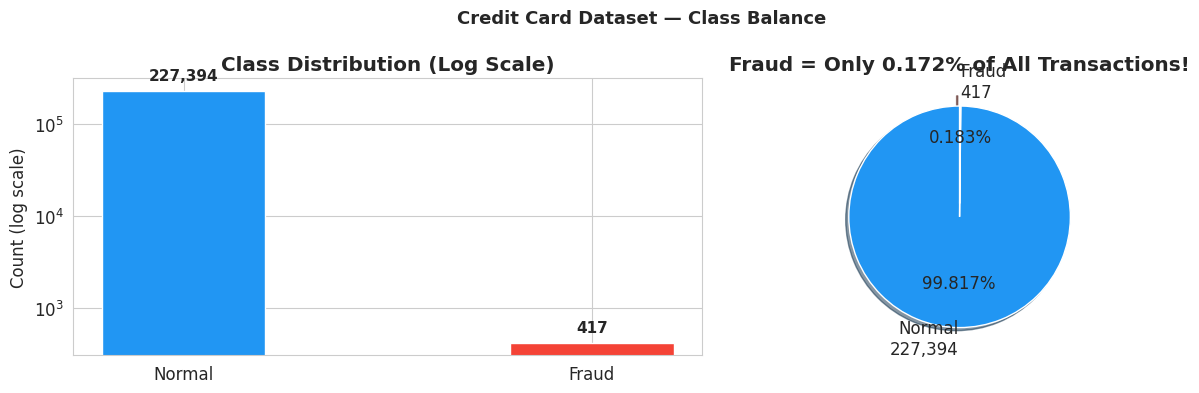

Saved viz1_class_distribution.png
KEY INSIGHT: Extreme imbalance → Unsupervised Anomaly Detection is the right approach!


In [ ]:
# VIZ 1 — Class Distribution
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(['Normal', 'Fraud'], [normal, fraud],
            color=['#2196F3', '#F44336'], edgecolor='white', width=0.4)
axes[0].set_yscale('log')
axes[0].set_ylabel('Count (log scale)')
axes[0].set_title('Class Distribution (Log Scale)', fontweight='bold')
for i, v in enumerate([normal, fraud]):
    axes[0].text(i, v * 1.3, f'{v:,}', ha='center', fontsize=11, fontweight='bold')

axes[1].pie([normal, fraud],
            labels=[f'Normal\n{normal:,}', f'Fraud\n{fraud}'],
            colors=['#2196F3', '#F44336'],
            autopct='%1.3f%%', startangle=90, explode=(0, 0.12), shadow=True)
axes[1].set_title('Fraud = Only 0.172% of All Transactions!', fontweight='bold')

plt.suptitle('Credit Card Dataset — Class Balance', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('viz1_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved viz1_class_distribution.png')
print('KEY INSIGHT: Extreme imbalance → Unsupervised Anomaly Detection is the right approach!')

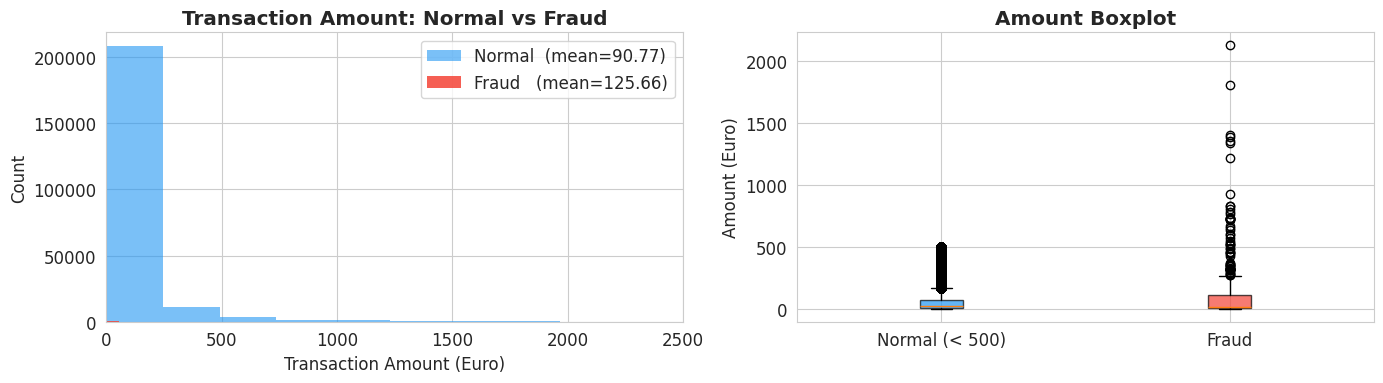

Normal avg: 90.77   Fraud avg: 125.66


In [ ]:
# VIZ 2 — Amount Distribution: Normal vs Fraud
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

fraud_amt  = df[df['Class'] == 1]['Amount']
normal_amt = df[df['Class'] == 0]['Amount']

axes[0].hist(normal_amt, bins=80, color='#2196F3', alpha=0.6,
             label=f'Normal  (mean={normal_amt.mean():.2f})', edgecolor='none')
axes[0].hist(fraud_amt,  bins=40, color='#F44336', alpha=0.85,
             label=f'Fraud   (mean={fraud_amt.mean():.2f})', edgecolor='none')
axes[0].set_xlim(0, 2500)
axes[0].set_xlabel('Transaction Amount (Euro)')
axes[0].set_ylabel('Count')
axes[0].set_title('Transaction Amount: Normal vs Fraud', fontweight='bold')
axes[0].legend()

bp = axes[1].boxplot(
    [normal_amt[normal_amt < 500].values, fraud_amt.values],
    labels=['Normal (< 500)', 'Fraud'],
    patch_artist=True
)
for patch, c in zip(bp['boxes'], ['#2196F3', '#F44336']):
    patch.set_facecolor(c)
    patch.set_alpha(0.7)
axes[1].set_ylabel('Amount (Euro)')
axes[1].set_title('Amount Boxplot', fontweight='bold')

plt.tight_layout()
plt.savefig('viz2_amount_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Normal avg: {normal_amt.mean():.2f}   Fraud avg: {fraud_amt.mean():.2f}')

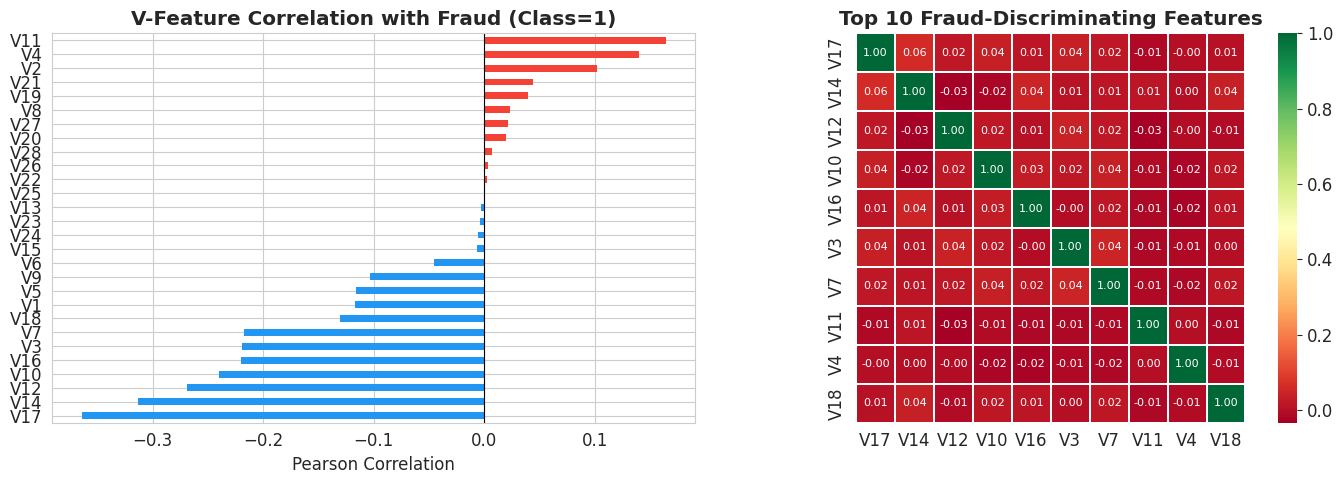

KEY INSIGHT: V17, V14, V12, V10 most strongly discriminate fraud from normal!


In [ ]:
# VIZ 3 — Feature Correlation with Fraud Class
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

v_cols = [f'V{i}' for i in range(1, 29)]
corr_fraud = df[v_cols + ['Class']].corr()['Class'][:-1].sort_values()
colors_c = ['#F44336' if c > 0 else '#2196F3' for c in corr_fraud]
corr_fraud.plot(kind='barh', color=colors_c, ax=axes[0], edgecolor='none')
axes[0].axvline(0, color='black', lw=0.8)
axes[0].set_title('V-Feature Correlation with Fraud (Class=1)', fontweight='bold')
axes[0].set_xlabel('Pearson Correlation')

top_feats = corr_fraud.abs().nlargest(10).index.tolist()
sns.heatmap(df[top_feats].corr(), annot=True, fmt='.2f',
            cmap='RdYlGn', ax=axes[1], square=True,
            linewidths=0.3, annot_kws={'size': 8})
axes[1].set_title('Top 10 Fraud-Discriminating Features', fontweight='bold')

plt.tight_layout()
plt.savefig('viz3_feature_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print('KEY INSIGHT: V17, V14, V12, V10 most strongly discriminate fraud from normal!')

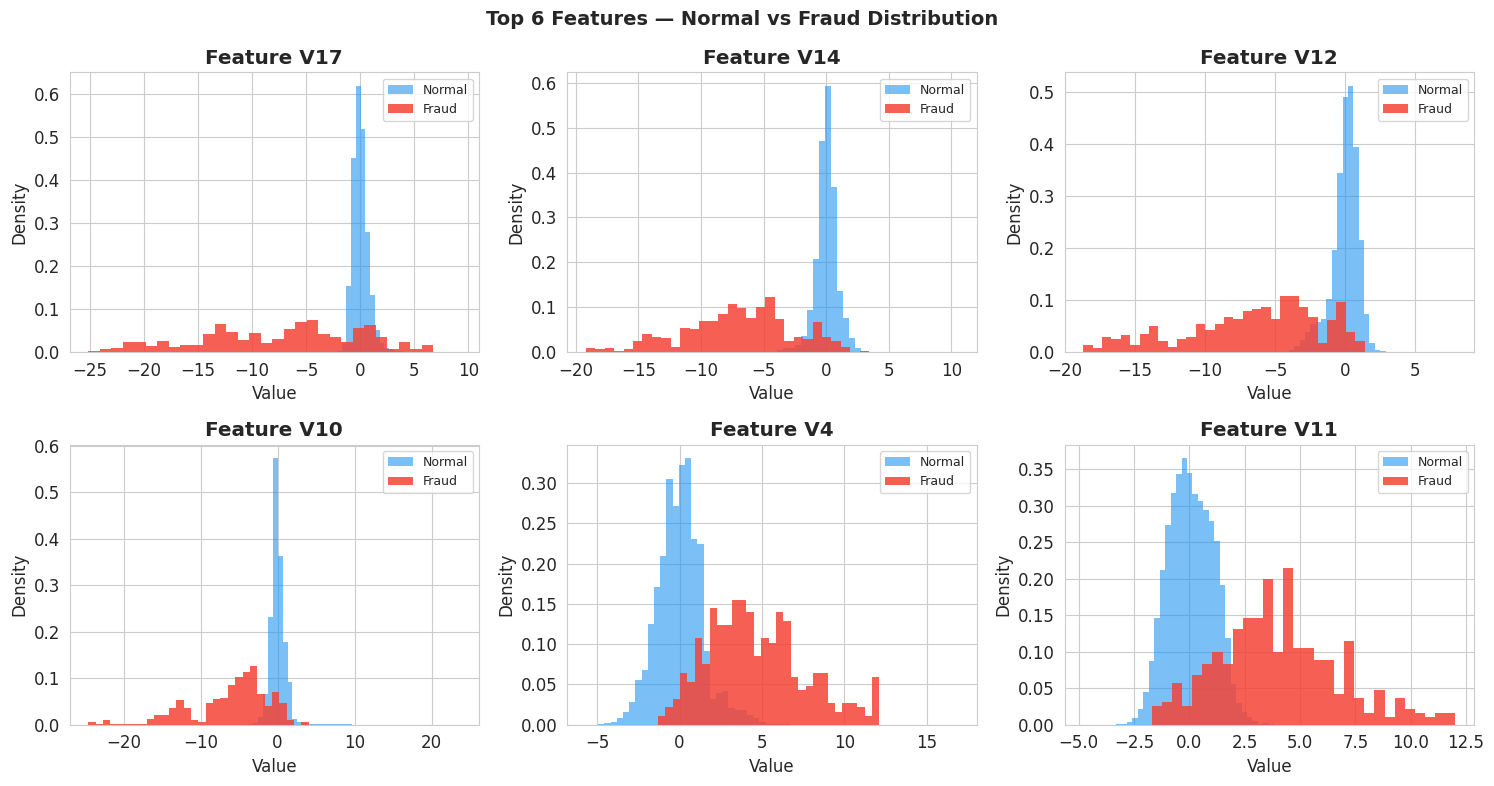

Fraud (red) has very different distributions — the model exploits this!


In [ ]:
# VIZ 4 — Top 6 Feature Distributions
top6 = ['V17', 'V14', 'V12', 'V10', 'V4', 'V11']
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, feat in enumerate(top6):
    axes[i].hist(df[df['Class'] == 0][feat], bins=60, color='#2196F3',
                 alpha=0.6, density=True, label='Normal', edgecolor='none')
    axes[i].hist(df[df['Class'] == 1][feat], bins=30, color='#F44336',
                 alpha=0.85, density=True, label='Fraud', edgecolor='none')
    axes[i].set_title(f'Feature {feat}', fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Density')
    axes[i].legend(fontsize=9)

plt.suptitle('Top 6 Features — Normal vs Fraud Distribution',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('viz4_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Fraud (red) has very different distributions — the model exploits this!')

Building PCA 2D visualization (5,000 sample)...


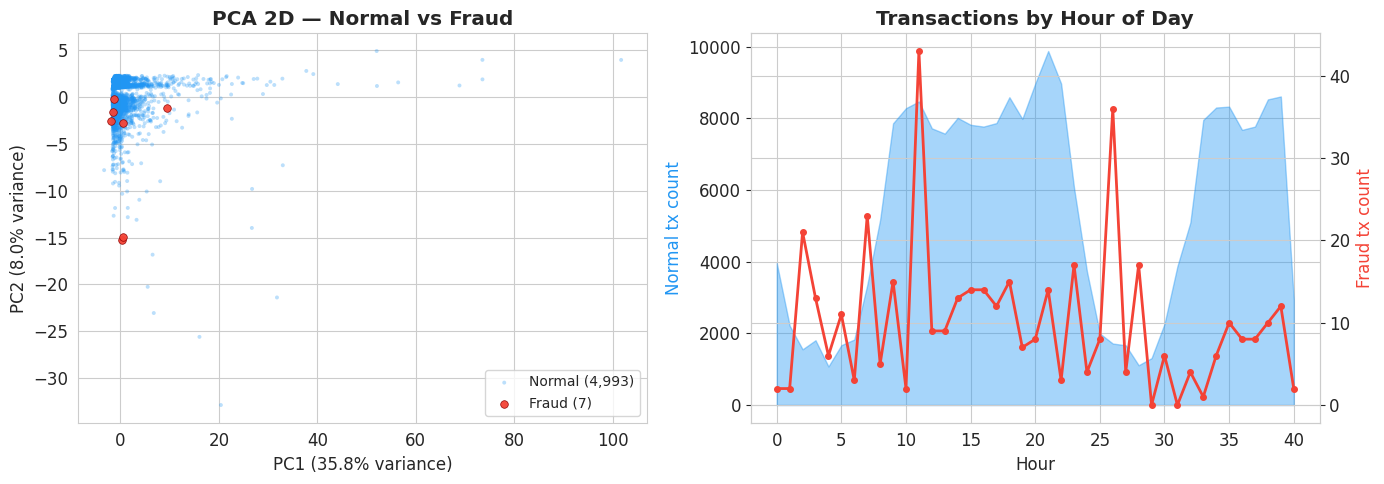

Fraud points (red) visibly separate from normal cluster in 2D!


In [ ]:
# VIZ 5 — PCA 2D Projection + Time Pattern
print('Building PCA 2D visualization (5,000 sample)...')

idx = np.random.choice(len(X), 5000, replace=False)
pca = PCA(n_components=2, random_state=42)
X2d = pca.fit_transform(X[idx])
y2d = y[idx]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

nm = y2d == 0
fr = y2d == 1
axes[0].scatter(X2d[nm, 0], X2d[nm, 1], c='#2196F3', alpha=0.3,
                s=8, label=f'Normal ({nm.sum():,})', edgecolors='none')
axes[0].scatter(X2d[fr, 0], X2d[fr, 1], c='#F44336', alpha=0.95,
                s=30, label=f'Fraud ({fr.sum()})',
                edgecolors='darkred', linewidths=0.5)
axes[0].set_title('PCA 2D — Normal vs Fraud', fontweight='bold')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
axes[0].legend(fontsize=10)

df['Hour'] = (df['Time'] // 3600).astype(int)
hourly = df.groupby(['Hour', 'Class']).size().unstack(fill_value=0)
axes[1].fill_between(hourly.index, hourly[0], alpha=0.4, color='#2196F3', label='Normal')
ax_r = axes[1].twinx()
ax_r.plot(hourly.index, hourly.get(1, pd.Series(0, index=hourly.index)),
          color='#F44336', lw=2, marker='o', ms=4, label='Fraud')
axes[1].set_xlabel('Hour')
axes[1].set_ylabel('Normal tx count', color='#2196F3')
ax_r.set_ylabel('Fraud tx count', color='#F44336')
axes[1].set_title('Transactions by Hour of Day', fontweight='bold')

plt.tight_layout()
plt.savefig('viz5_pca_and_time.png', dpi=150, bbox_inches='tight')
plt.show()
print('Fraud points (red) visibly separate from normal cluster in 2D!')

In [ ]:
print(f'Training Isolation Forest (200 trees) on {len(X):,} transactions...')
print(f'Contamination: {fraud_rate:.5f}  ({fraud_rate*100:.3f}%)')

iso = IsolationForest(
    n_estimators  = 200,
    contamination = fraud_rate,
    max_samples   = 'auto',
    random_state  = 42,
    n_jobs        = -1
)
iso.fit(X)   # No labels — purely unsupervised

iso_raw    = iso.predict(X)
iso_pred   = np.where(iso_raw == -1, 1, 0)
iso_scores = -iso.score_samples(X)

detected_iso  = int(np.sum((iso_pred == 1) & (y == 1)))
false_pos_iso = int(np.sum((iso_pred == 1) & (y == 0)))
iso_auc       = float(roc_auc_score(y, iso_scores))

print()
print('=' * 48)
print('   ISOLATION FOREST  RESULTS')
print('=' * 48)
print(f'  Fraud detected  : {detected_iso} / {fraud}  ({detected_iso/fraud*100:.1f}%)')
print(f'  False alarms    : {false_pos_iso}')
print(f'  ROC-AUC         : {iso_auc:.4f}')
print('=' * 48)
print()
print(classification_report(y, iso_pred, target_names=['Normal', 'Fraud']))

Training Isolation Forest (200 trees) on 227,810 transactions...
Contamination: 0.00183  (0.183%)

   ISOLATION FOREST  RESULTS
  Fraud detected  : 131 / 417  (31.4%)
  False alarms    : 286
  ROC-AUC         : 0.9465

              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00    227393
       Fraud       0.31      0.31      0.31       417

    accuracy                           1.00    227810
   macro avg       0.66      0.66      0.66    227810
weighted avg       1.00      1.00      1.00    227810



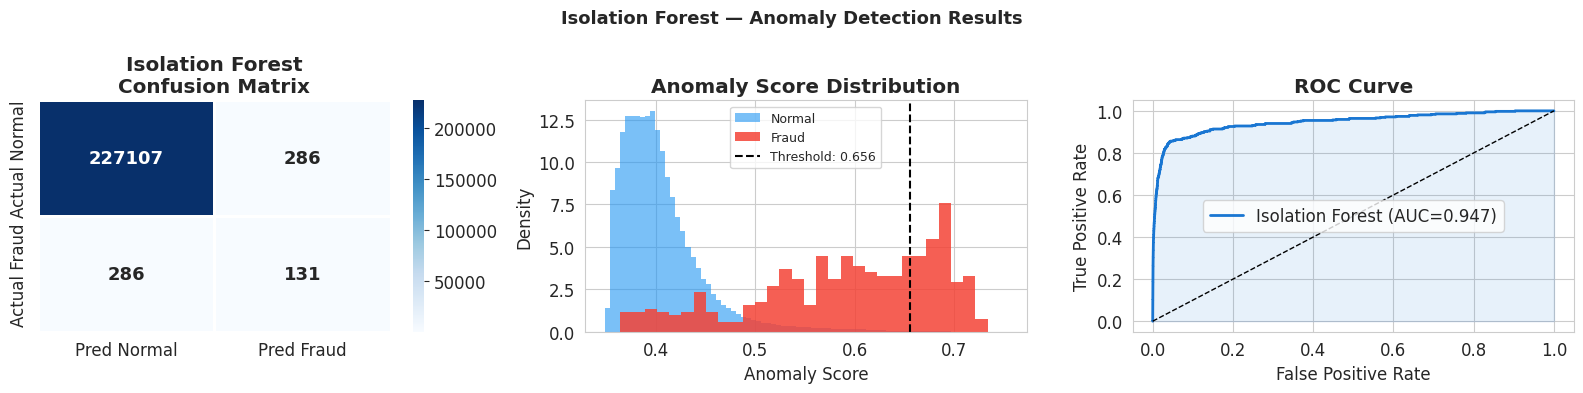

Saved viz6_isolation_forest.png


In [ ]:
# VIZ 6 — Isolation Forest Results
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

cm_iso = confusion_matrix(y, iso_pred)
sns.heatmap(cm_iso, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Pred Normal', 'Pred Fraud'],
            yticklabels=['Actual Normal', 'Actual Fraud'],
            linewidths=1, annot_kws={'size': 13, 'weight': 'bold'})
axes[0].set_title('Isolation Forest\nConfusion Matrix', fontweight='bold')

axes[1].hist(iso_scores[y == 0], bins=80, color='#2196F3', alpha=0.6,
             density=True, label='Normal', edgecolor='none')
axes[1].hist(iso_scores[y == 1], bins=30, color='#F44336', alpha=0.85,
             density=True, label='Fraud', edgecolor='none')
thresh_iso = float(np.percentile(iso_scores, (1 - fraud_rate) * 100))
axes[1].axvline(thresh_iso, color='black', lw=1.5, ls='--',
                label=f'Threshold: {thresh_iso:.3f}')
axes[1].set_xlabel('Anomaly Score')
axes[1].set_ylabel('Density')
axes[1].set_title('Anomaly Score Distribution', fontweight='bold')
axes[1].legend(fontsize=9)

fpr_iso, tpr_iso, _ = roc_curve(y, iso_scores)
axes[2].plot(fpr_iso, tpr_iso, color='#1976D2', lw=2,
             label=f'Isolation Forest (AUC={iso_auc:.3f})')
axes[2].plot([0, 1], [0, 1], 'k--', lw=1)
axes[2].fill_between(fpr_iso, tpr_iso, alpha=0.1, color='#1976D2')
axes[2].set_xlabel('False Positive Rate')
axes[2].set_ylabel('True Positive Rate')
axes[2].set_title('ROC Curve', fontweight='bold')
axes[2].legend()

plt.suptitle('Isolation Forest — Anomaly Detection Results',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('viz6_isolation_forest.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved viz6_isolation_forest.png')

---
## 🧠 Step 7 — Model 2: Autoencoder Neural Network

**Architecture:**
```
Input(30) → Dense(16, relu) → Dense(8, relu)     ← Encoder (compress)
          → Dense(16, relu) → Dense(30, linear)  ← Decoder (reconstruct)
```
**Key idea:** Trained ONLY on normal transactions. Learns to perfectly reconstruct
normal patterns. Fraud transactions → HIGH reconstruction error → flagged as anomaly.

In [ ]:
# Prepare — train ONLY on normal transactions
std_sc   = StandardScaler()
X_norm_sc = std_sc.fit_transform(X_normal)
X_all_sc  = std_sc.transform(X)

sp    = int(len(X_norm_sc) * 0.8)
X_tr  = X_norm_sc[:sp]
X_vl  = X_norm_sc[sp:]
n_feat = X.shape[1]

# Build Autoencoder
inp  = Input(shape=(n_feat,))
enc1 = Dense(16, activation='relu')(inp)
enc2 = Dense(8,  activation='relu')(enc1)   # bottleneck
dec1 = Dense(16, activation='relu')(enc2)
out  = Dense(n_feat, activation='linear')(dec1)

ae = Model(inp, out)
ae.compile(optimizer='adam', loss='mse')
ae.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 30)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 30)             │           510 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,286 (5.02 KB)

 Trainable params: 1,286 (5.02 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
print('Training Autoencoder on NORMAL transactions only...')

history = ae.fit(
    X_tr, X_tr,
    epochs=50,
    batch_size=256,
    validation_data=(X_vl, X_vl),
    callbacks=[EarlyStopping(monitor='val_loss', patience=5,
                             restore_best_weights=True)],
    verbose=1
)
print(f'\nStopped at epoch {len(history.history["loss"])}')

Training Autoencoder on NORMAL transactions only...
Epoch 1/50
711/711 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - loss: 0.7566 - val_loss: 0.8817
Epoch 2/50
711/711 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.5633 - val_loss: 0.7990
Epoch 3/50
711/711 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.5158 - val_loss: 0.7561
Epoch 4/50
711/711 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.4886 - val_loss: 0.7230
Epoch 5/50
711/711 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.4694 - val_loss: 0.7025
Epoch 6/50
711/711 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.4558 - val_loss: 0.6919
Epoch 7/50
711/711 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.4452 - val_loss: 0.6842
Epoch 8/50
711/711 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.4361 - val_loss: 0.6781
Epoch 9/50
711/711 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.4289 - val_loss: 0.6734
Epoch 10/50
711/711 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.4230 - val_loss: 0.6695
Epoch 11/50
711/711 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.4177 - val_loss: 0.6652


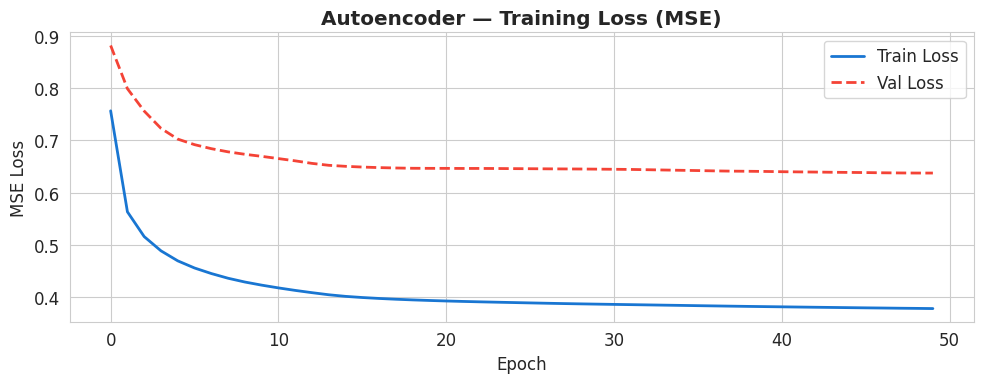

In [ ]:
# VIZ 7 — Training Loss Curve
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'],     color='#1976D2', lw=2, label='Train Loss')
plt.plot(history.history['val_loss'], color='#F44336', lw=2, label='Val Loss', ls='--')
plt.title('Autoencoder — Training Loss (MSE)', fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.tight_layout()
plt.savefig('viz7_ae_loss.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Reconstruction error for all transactions
X_rec   = ae.predict(X_all_sc, verbose=0)
rec_err = np.mean(np.power(X_all_sc - X_rec, 2), axis=1)

thresh_ae = float(np.percentile(rec_err, (1 - fraud_rate) * 100))
ae_pred   = (rec_err > thresh_ae).astype(int)

detected_ae  = int(np.sum((ae_pred == 1) & (y == 1)))
false_pos_ae = int(np.sum((ae_pred == 1) & (y == 0)))
ae_auc       = float(roc_auc_score(y, rec_err))

print(f'Normal avg reconstruction error : {rec_err[y==0].mean():.6f}')
print(f'Fraud  avg reconstruction error : {rec_err[y==1].mean():.6f}')
ratio = rec_err[y==1].mean() / rec_err[y==0].mean()
print(f'Ratio (fraud/normal)            : {ratio:.1f}x higher!')
print()
print('=' * 48)
print('   AUTOENCODER  RESULTS')
print('=' * 48)
print(f'  Fraud detected  : {detected_ae} / {fraud}  ({detected_ae/fraud*100:.1f}%)')
print(f'  False alarms    : {false_pos_ae}')
print(f'  ROC-AUC         : {ae_auc:.4f}')
print('=' * 48)
print()
print(classification_report(y, ae_pred, target_names=['Normal', 'Fraud']))

Normal avg reconstruction error : 0.429546
Fraud  avg reconstruction error : 23.457254
Ratio (fraud/normal)            : 54.6x higher!

   AUTOENCODER  RESULTS
  Fraud detected  : 162 / 417  (38.8%)
  False alarms    : 255
  ROC-AUC         : 0.9367

              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00    227393
       Fraud       0.39      0.39      0.39       417

    accuracy                           1.00    227810
   macro avg       0.69      0.69      0.69    227810
weighted avg       1.00      1.00      1.00    227810



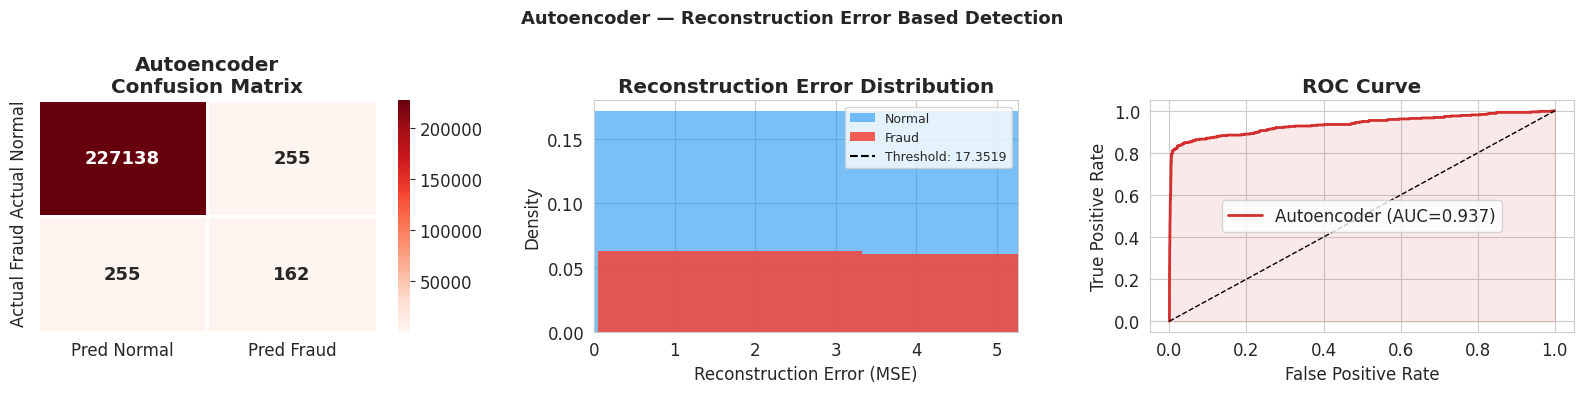

Saved viz8_autoencoder.png


In [ ]:
# VIZ 8 — Autoencoder Results
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

cm_ae = confusion_matrix(y, ae_pred)
sns.heatmap(cm_ae, annot=True, fmt='d', cmap='Reds', ax=axes[0],
            xticklabels=['Pred Normal', 'Pred Fraud'],
            yticklabels=['Actual Normal', 'Actual Fraud'],
            linewidths=1, annot_kws={'size': 13, 'weight': 'bold'})
axes[0].set_title('Autoencoder\nConfusion Matrix', fontweight='bold')

clip = float(np.percentile(rec_err, 99.5))
axes[1].hist(rec_err[y == 0], bins=80, color='#2196F3', alpha=0.6,
             density=True, label='Normal', edgecolor='none')
axes[1].hist(rec_err[y == 1], bins=30, color='#F44336', alpha=0.85,
             density=True, label='Fraud', edgecolor='none')
axes[1].axvline(thresh_ae, color='black', lw=1.5, ls='--',
                label=f'Threshold: {thresh_ae:.4f}')
axes[1].set_xlim(0, clip)
axes[1].set_xlabel('Reconstruction Error (MSE)')
axes[1].set_ylabel('Density')
axes[1].set_title('Reconstruction Error Distribution', fontweight='bold')
axes[1].legend(fontsize=9)

fpr_ae, tpr_ae, _ = roc_curve(y, rec_err)
axes[2].plot(fpr_ae, tpr_ae, color='#D32F2F', lw=2,
             label=f'Autoencoder (AUC={ae_auc:.3f})')
axes[2].plot([0, 1], [0, 1], 'k--', lw=1)
axes[2].fill_between(fpr_ae, tpr_ae, alpha=0.1, color='#D32F2F')
axes[2].set_xlabel('False Positive Rate')
axes[2].set_ylabel('True Positive Rate')
axes[2].set_title('ROC Curve', fontweight='bold')
axes[2].legend()

plt.suptitle('Autoencoder — Reconstruction Error Based Detection',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('viz8_autoencoder.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved viz8_autoencoder.png')

---
## ⚖️ Step 8 — Model Comparison

In [ ]:
ap_iso = float(average_precision_score(y, iso_scores))
ap_ae  = float(average_precision_score(y, rec_err))

comp = pd.DataFrame({
    'Metric': ['Fraud Detected', 'Detection Rate', 'False Alarms',
               'Precision', 'Recall', 'F1 Score', 'ROC-AUC', 'Avg Precision'],
    'Isolation Forest': [
        f'{detected_iso}/{fraud}',
        f'{detected_iso/fraud*100:.1f}%',
        str(false_pos_iso),
        f'{precision_score(y, iso_pred):.4f}',
        f'{recall_score(y, iso_pred):.4f}',
        f'{f1_score(y, iso_pred):.4f}',
        f'{iso_auc:.4f}',
        f'{ap_iso:.4f}'
    ],
    'Autoencoder': [
        f'{detected_ae}/{fraud}',
        f'{detected_ae/fraud*100:.1f}%',
        str(false_pos_ae),
        f'{precision_score(y, ae_pred):.4f}',
        f'{recall_score(y, ae_pred):.4f}',
        f'{f1_score(y, ae_pred):.4f}',
        f'{ae_auc:.4f}',
        f'{ap_ae:.4f}'
    ]
}).set_index('Metric')

print('Model Comparison Table:')
print('=' * 55)
print(comp.to_string())
print('=' * 55)
winner = 'Autoencoder' if ae_auc > iso_auc else 'Isolation Forest'
print(f'\nBest model by ROC-AUC: {winner}')

Model Comparison Table:
               Isolation Forest Autoencoder
Metric                                     
Fraud Detected          131/417     162/417
Detection Rate            31.4%       38.8%
False Alarms                286         255
Precision                0.3141      0.3885
Recall                   0.3141      0.3885
F1 Score                 0.3141      0.3885
ROC-AUC                  0.9465      0.9367
Avg Precision            0.1920      0.3160

Best model by ROC-AUC: Isolation Forest


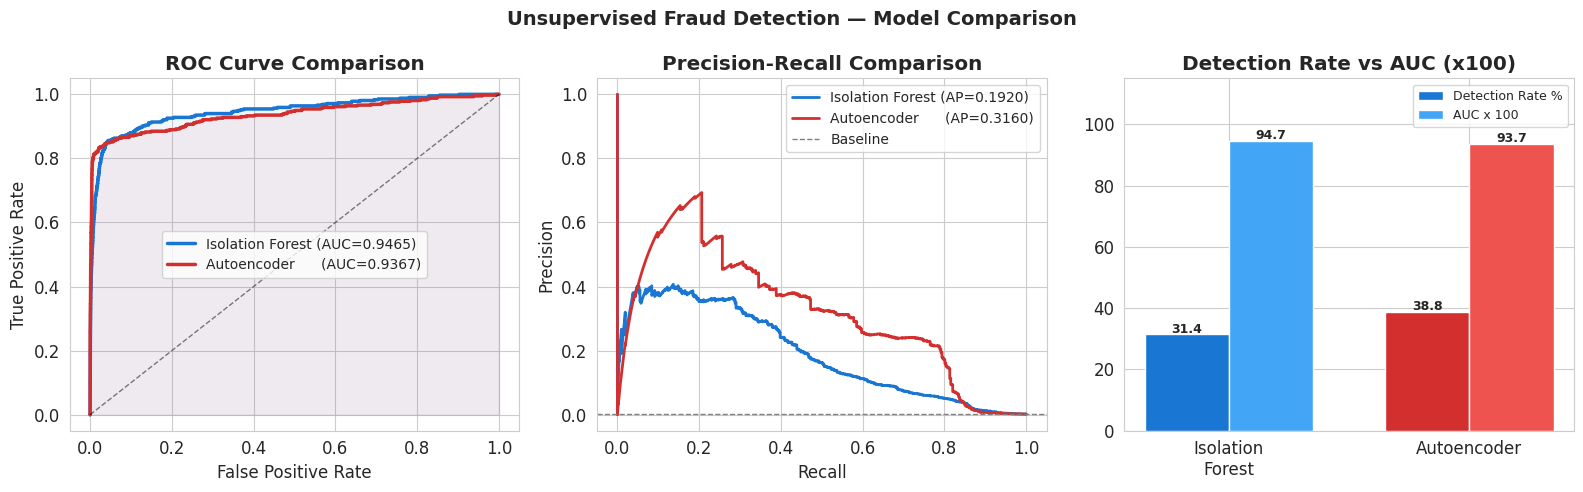

Saved viz9_model_comparison.png


In [ ]:
# VIZ 9 — Full Comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].plot(fpr_iso, tpr_iso, color='#1976D2', lw=2.5,
             label=f'Isolation Forest (AUC={iso_auc:.4f})')
axes[0].plot(fpr_ae, tpr_ae, color='#D32F2F', lw=2.5,
             label=f'Autoencoder      (AUC={ae_auc:.4f})')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
axes[0].fill_between(fpr_iso, tpr_iso, alpha=0.06, color='#1976D2')
axes[0].fill_between(fpr_ae, tpr_ae, alpha=0.06, color='#D32F2F')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve Comparison', fontweight='bold')
axes[0].legend(fontsize=10)

prec_i, rec_i, _ = precision_recall_curve(y, iso_scores)
prec_a, rec_a, _ = precision_recall_curve(y, rec_err)
axes[1].plot(rec_i, prec_i, color='#1976D2', lw=2,
             label=f'Isolation Forest (AP={ap_iso:.4f})')
axes[1].plot(rec_a, prec_a, color='#D32F2F', lw=2,
             label=f'Autoencoder      (AP={ap_ae:.4f})')
axes[1].axhline(fraud_rate, color='gray', lw=1, ls='--', label='Baseline')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Comparison', fontweight='bold')
axes[1].legend(fontsize=10)

cats = ['Isolation\nForest', 'Autoencoder']
xp   = np.arange(2)
w    = 0.35
b1   = axes[2].bar(xp - w/2, [detected_iso/fraud*100, detected_ae/fraud*100],
                   w, color=['#1976D2', '#D32F2F'], label='Detection Rate %')
b2   = axes[2].bar(xp + w/2, [iso_auc*100, ae_auc*100],
                   w, color=['#42A5F5', '#EF5350'], label='AUC x 100')
for b in list(b1) + list(b2):
    axes[2].text(b.get_x() + b.get_width()/2, b.get_height() + 0.5,
                 f'{b.get_height():.1f}', ha='center', fontsize=9, fontweight='bold')
axes[2].set_xticks(xp)
axes[2].set_xticklabels(cats)
axes[2].set_ylim(0, 115)
axes[2].set_title('Detection Rate vs AUC (x100)', fontweight='bold')
axes[2].legend(fontsize=9)

plt.suptitle('Unsupervised Fraud Detection — Model Comparison',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('viz9_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved viz9_model_comparison.png')

---
## 🔮 Step 9 — Prediction Demo & Final Summary

In [ ]:
# Predict on 5 normal + 5 fraud transactions
norm_idx  = np.where(y == 0)[0][:5]
fraud_idx = np.where(y == 1)[0][:5]
samp      = np.concatenate([norm_idx, fraud_idx])

demo = pd.DataFrame({
    'Transaction_ID'   : samp,
    'True Label'       : ['FRAUD' if y[i] == 1 else 'Normal' for i in samp],
    'IsoForest Pred'   : ['FRAUD' if iso_pred[i] == 1 else 'Normal' for i in samp],
    'Autoencoder Pred' : ['FRAUD' if ae_pred[i]  == 1 else 'Normal' for i in samp],
    'Anomaly Score'    : [round(float(iso_scores[i]), 4) for i in samp],
    'Recon Error'      : [round(float(rec_err[i]),    6) for i in samp]
})
print('Prediction Demo — 5 Normal + 5 Fraud Transactions:')
print('=' * 80)
print(demo.to_string(index=False))
print('=' * 80)

Prediction Demo — 5 Normal + 5 Fraud Transactions:
 Transaction_ID True Label IsoForest Pred Autoencoder Pred  Anomaly Score  Recon Error
              0     Normal         Normal           Normal         0.3807     0.264359
              1     Normal         Normal           Normal         0.3701     0.121533
              2     Normal         Normal           Normal         0.4750     0.839220
              3     Normal         Normal           Normal         0.4093     0.614764
              4     Normal         Normal           Normal         0.3941     0.275359
            541      FRAUD         Normal           Normal         0.5076     3.157384
            623      FRAUD         Normal           Normal         0.4999     0.855912
           4920      FRAUD         Normal           Normal         0.5015     3.670138
           6108      FRAUD         Normal            FRAUD         0.5886    20.709026
           6329      FRAUD         Normal           Normal         0.5932     1

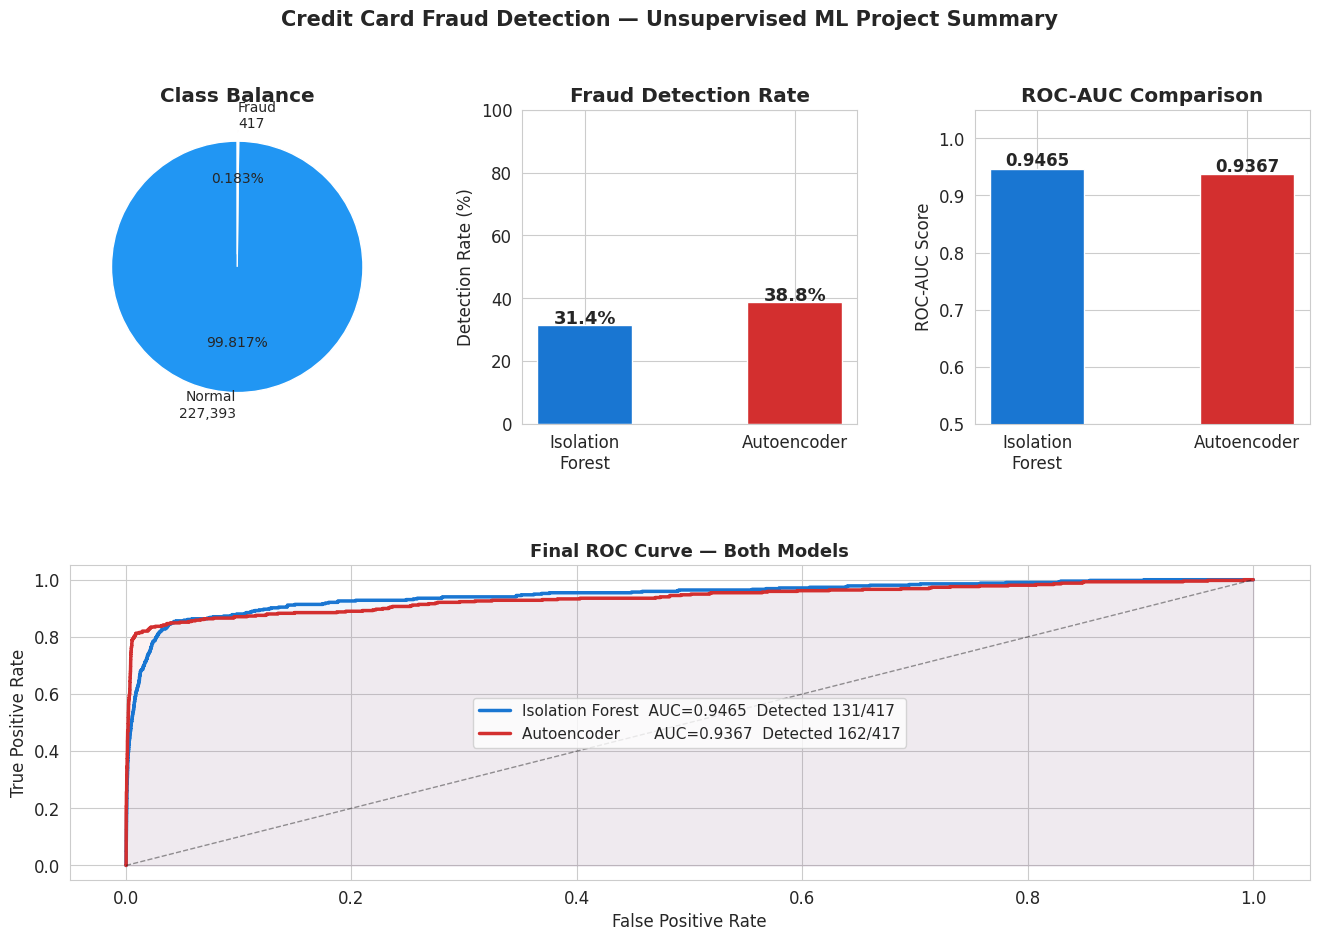

Saved viz10_final_summary.png


In [ ]:
# VIZ 10 — Final Summary Dashboard
fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 3, hspace=0.45, wspace=0.35)

ax1 = fig.add_subplot(gs[0, 0])
ax1.pie([normal, fraud],
        labels=[f'Normal\n{normal:,}', f'Fraud\n{fraud}'],
        colors=['#2196F3', '#F44336'], autopct='%1.3f%%',
        startangle=90, explode=(0, 0.1), textprops={'fontsize': 10})
ax1.set_title('Class Balance', fontweight='bold')

ax2 = fig.add_subplot(gs[0, 1])
bars2 = ax2.bar(['Isolation\nForest', 'Autoencoder'],
                [detected_iso/fraud*100, detected_ae/fraud*100],
                color=['#1976D2', '#D32F2F'], edgecolor='white', width=0.45)
for b in bars2:
    ax2.text(b.get_x() + b.get_width()/2, b.get_height() + 0.5,
             f'{b.get_height():.1f}%', ha='center', fontsize=13, fontweight='bold')
ax2.set_ylim(0, 100)
ax2.set_ylabel('Detection Rate (%)')
ax2.set_title('Fraud Detection Rate', fontweight='bold')

ax3 = fig.add_subplot(gs[0, 2])
bars3 = ax3.bar(['Isolation\nForest', 'Autoencoder'],
                [iso_auc, ae_auc],
                color=['#1976D2', '#D32F2F'], edgecolor='white', width=0.45)
for b in bars3:
    ax3.text(b.get_x() + b.get_width()/2, b.get_height() + 0.005,
             f'{b.get_height():.4f}', ha='center', fontsize=12, fontweight='bold')
ax3.set_ylim(0.5, 1.05)
ax3.set_ylabel('ROC-AUC Score')
ax3.set_title('ROC-AUC Comparison', fontweight='bold')

ax4 = fig.add_subplot(gs[1, :])
ax4.plot(fpr_iso, tpr_iso, color='#1976D2', lw=2.5,
         label=f'Isolation Forest  AUC={iso_auc:.4f}  Detected {detected_iso}/{fraud}')
ax4.plot(fpr_ae, tpr_ae, color='#D32F2F', lw=2.5,
         label=f'Autoencoder       AUC={ae_auc:.4f}  Detected {detected_ae}/{fraud}')
ax4.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.4)
ax4.fill_between(fpr_iso, tpr_iso, alpha=0.06, color='#1976D2')
ax4.fill_between(fpr_ae, tpr_ae, alpha=0.06, color='#D32F2F')
ax4.set_xlabel('False Positive Rate', fontsize=12)
ax4.set_ylabel('True Positive Rate', fontsize=12)
ax4.set_title('Final ROC Curve — Both Models', fontweight='bold', fontsize=13)
ax4.legend(fontsize=11)

plt.suptitle('Credit Card Fraud Detection — Unsupervised ML Project Summary',
             fontsize=15, fontweight='bold')
plt.savefig('viz10_final_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved viz10_final_summary.png')

In [ ]:
print()
print('=' * 60)
print('  MAJOR PROJECT  UNSUPERVISED MACHINE LEARNING')
print('  Credit Card Fraud Detection')
print('=' * 60)
print(f'  Dataset        : Kaggle Credit Card Fraud ({len(df):,} rows)')
print(f'  Fraud rate     : {fraud_rate*100:.4f}%  ({fraud} out of {total:,})')
print(f'  Features       : {X.shape[1]}  (V1-V28 + scaled Time + Amount)')
print(f'  Learning type  : Unsupervised Anomaly Detection')
print('-' * 60)
print(f'  Isolation Forest')
print(f'    Fraud detected : {detected_iso}/{fraud}  ({detected_iso/fraud*100:.1f}%)')
print(f'    ROC-AUC        : {iso_auc:.4f}')
print(f'    Avg Precision  : {ap_iso:.4f}')
print('-' * 60)
print(f'  Autoencoder Neural Network')
print(f'    Fraud detected : {detected_ae}/{fraud}  ({detected_ae/fraud*100:.1f}%)')
print(f'    ROC-AUC        : {ae_auc:.4f}')
print(f'    Avg Precision  : {ap_ae:.4f}')
print('-' * 60)
print(f'  Best Model     : {winner}')
print('=' * 60)
print()
charts = [
    'viz1_class_distribution',   'viz2_amount_distribution',
    'viz3_feature_correlation',  'viz4_feature_distributions',
    'viz5_pca_and_time',         'viz6_isolation_forest',
    'viz7_ae_loss',              'viz8_autoencoder',
    'viz9_model_comparison',     'viz10_final_summary'
]
print('Visualizations saved (10 charts):')
for i, name in enumerate(charts, 1):
    print(f'  {i:02d}. {name}.png')


  MAJOR PROJECT  UNSUPERVISED MACHINE LEARNING
  Credit Card Fraud Detection
  Dataset        : Kaggle Credit Card Fraud (227,810 rows)
  Fraud rate     : 0.1830%  (417 out of 227,810)
  Features       : 30  (V1-V28 + scaled Time + Amount)
  Learning type  : Unsupervised Anomaly Detection
------------------------------------------------------------
  Isolation Forest
    Fraud detected : 131/417  (31.4%)
    ROC-AUC        : 0.9465
    Avg Precision  : 0.1920
------------------------------------------------------------
  Autoencoder Neural Network
    Fraud detected : 162/417  (38.8%)
    ROC-AUC        : 0.9367
    Avg Precision  : 0.3160
------------------------------------------------------------
  Best Model     : Isolation Forest

Visualizations saved (10 charts):
  01. viz1_class_distribution.png
  02. viz2_amount_distribution.png
  03. viz3_feature_correlation.png
  04. viz4_feature_distributions.png
  05. viz5_pca_and_time.png
  06. viz6_isolation_forest.png
  07. viz7_ae_loss